# Inflation Base Effects: Data and Mechanism

## Objective

Test the proposed expectations channel: does the CPI print rolling out of the
12-month year-over-year window predict subsequent revisions to inflation
forecasts?

The notebook defaults to the committed **2026-09-28 snapshot**. Live source
refreshes are deliberately separate so this saved result remains reproducible.


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from statsmodels.regression.linear_model import OLS

from inflation_base_effects.data import (
    compute_base_effect,
    load_cpi,
    load_michigan,
    load_spf,
    load_yields,
)
from inflation_base_effects.portfolio import compute_bond_returns

pd.options.display.float_format = "{:.4f}".format
plt.style.use("seaborn-v0_8-whitegrid")


Matplotlib is building the font cache; this may take a moment.


## Data and timing

- CPI levels are monthly, not seasonally adjusted.
- Sovereign yields are monthly averages; the US series is FRED `GS10`.
- Michigan revisions are monthly first differences in one-year expectations.
- SPF revisions compare the same target quarter, `CPI5_t - CPI6_{t-1}`, and
  are indexed to the official survey deadline month.


In [2]:
headline_nsa = load_cpi()
yields_monthly = load_yields()
inf_exp_rev = load_michigan()
spf_rev = load_spf()
bnd_ret_m, _ = compute_bond_returns(yields_monthly)
rolling_off = compute_base_effect(headline_nsa)


def coverage(frame):
    return pd.DataFrame(
        {
            "first": frame.apply(lambda s: s.dropna().index.min().strftime("%Y-%m")),
            "last": frame.apply(lambda s: s.dropna().index.max().strftime("%Y-%m")),
            "observations": frame.notna().sum(),
            "missing_pct": (100 * frame.isna().mean()).round(1),
        }
    )


display(coverage(headline_nsa).rename_axis("market"))
display(coverage(yields_monthly).rename_axis("market"))


,first,last,observations,missing_pct
market,,,,
B_EMU_BD,1990-01,2023-11,407,7.3000
B_UKI_BD,1990-01,2023-11,407,7.3000
B_CAN_BD,1990-01,2023-11,407,7.3000
B_USA_BD,1990-01,2026-08,439,0.0000


,first,last,observations,missing_pct
market,,,,
B_USA_BD,1990-01,2026-08,440,0.0000
B_EMU_BD,1990-01,2026-08,440,0.0000
B_UKI_BD,1990-01,2026-08,440,0.0000
B_CAN_BD,1990-01,2026-08,440,0.0000


## Mechanism regression

The regressor is the **negated** rolling-off print. A high old print therefore
creates a negative regressor and should predict a negative forecast revision,
implying a positive coefficient under the proposed channel. HAC standard errors
use the automatic Newey-West lag rule shown below.


In [3]:
def mechanism_regression(base_effect_pp, revision, label):
    frame = pd.concat(
        [base_effect_pp.rename("base"), revision.rename("revision")], axis=1
    ).dropna()
    lags = max(int(np.floor(4 * (len(frame) / 100) ** (2 / 9))), 1)
    design = np.column_stack([np.ones(len(frame)), frame["base"].to_numpy()])
    result = OLS(frame["revision"].to_numpy(), design).fit(
        cov_type="HAC", cov_kwds={"maxlags": lags}
    )
    interval = result.conf_int()[1]
    return {
        "series": label,
        "N": len(frame),
        "NW lags": lags,
        "beta": result.params[1],
        "95% low": interval[0],
        "95% high": interval[1],
        "t-stat": result.tvalues[1],
        "p-value": result.pvalues[1],
        "R2": result.rsquared,
    }


base_effect_pp = -100 * rolling_off["B_USA_BD"]
mechanism_results = pd.DataFrame(
    [
        mechanism_regression(
            base_effect_pp.reindex(inf_exp_rev.index),
            inf_exp_rev["B_USA_BD"],
            "Michigan monthly revision",
        ),
        mechanism_regression(
            base_effect_pp.reindex(spf_rev.index),
            spf_rev["B_USA_BD"],
            "SPF same-target revision",
        ),
    ]
).set_index("series")
display(mechanism_results)


,N,NW lags,beta,95% low,95% high,t-stat,p-value,R2
series,,,,,,,,
Michigan monthly revision,426,5,-0.0736,-0.1869,0.0398,-1.2721,0.2033,0.0050
SPF same-target revision,143,4,-0.0301,-0.1234,0.0633,-0.6316,0.5277,0.0032


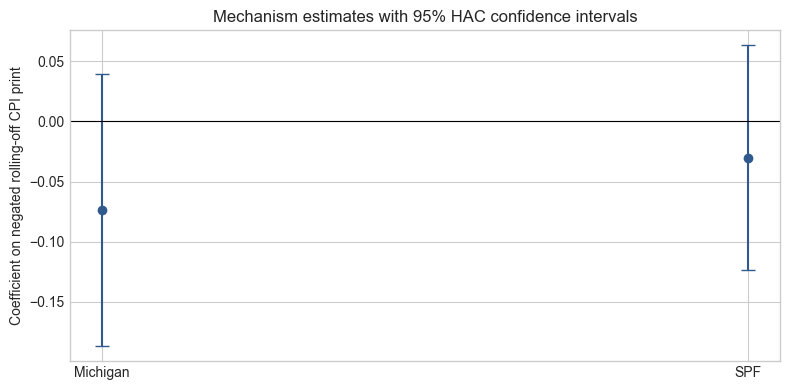

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(mechanism_results))
beta = mechanism_results["beta"].to_numpy()
lower = beta - mechanism_results["95% low"].to_numpy()
upper = mechanism_results["95% high"].to_numpy() - beta
ax.errorbar(x, beta, yerr=[lower, upper], fmt="o", capsize=5, color="#305a8d")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x, ["Michigan", "SPF"])
ax.set_ylabel("Coefficient on negated rolling-off CPI print")
ax.set_title("Mechanism estimates with 95% HAC confidence intervals")
plt.tight_layout()
plt.show()


## Interpretation

The table and confidence intervals are authoritative. The proposed mechanism
requires positive coefficients. The public proxies do not provide statistically
significant support for that channel. Michigan expectations also change horizon
through time, so the same-target SPF specification is the cleaner of the two.

This is a mechanism test, not evidence that the opposite trading direction is
profitable.
